In [1]:
%load_ext autoreload
%autoreload 2

# Imports / インポート

This notebook imports reusable modules that handle each stage of the HAR pipeline.

このノートブックでは、HAR パイプラインの各処理を担当するモジュールを読み込みます。

### Modules Included / 読み込むモジュール
- Data loading / データ読み込み
- Configuration / 設定
- Preprocessing / 前処理
- Feature engineering / 特徴量生成
- Model evaluation / モデル評価
- Visualization / 可視化

In [3]:
# ==========================================================
# Import project modules / プロジェクトモジュールの読み込み
# ==========================================================

# Load utility functions for reading datasets and formatting notebook output
# データセットの読み込みとノートブック出力を整形するユーティリティ
from har_utils.data import (
    get_subject,
    print_clean_header
)

# Load global configuration values shared across the project
# プロジェクト全体で使用する設定値を読み込む
from har_utils.config import FILE_NAME_SUFFIX

# Load preprocessing functions for data cleaning and feature preparation
# データクリーニングと特徴量生成前処理を行う関数
from har_utils.preprocessing import (
    do_sanity_check,
    preprocessing_pipeline,
    preprocess_all_subjects
)

# Load machine learning model constructors
# 機械学習モデルを生成する関数
from har_utils.model import model_random_forest


# Load evaluation utilities for training and performance analysis
# モデルの学習および性能評価を行う関数
from har_utils.analysis import (
    preprocess_evaluate_loso_supervised,
    run_optuna_study,
    evaluate_loso,
    get_feature_importance,
    filter_features_by_importance
)

import numpy as np
import pandas as pd
from tqdm.auto import tqdm

## Load Dataset / データセットの読み込み

Load the pose estimation data for each subject into a dictionary, where the subject ID is used as the key. Display the shape of each dataset to verify that all files were loaded successfully.

各被験者の姿勢推定データを辞書に読み込み、被験者IDをキーとして管理します。あわせて各データセットのサイズを表示し、正しく読み込まれたことを確認します。

In [4]:
# Load all subject datasets into a dictionary for easy access
# 各被験者のデータセットを辞書に読み込み、一括管理する
all_subject = {}

for suffix in FILE_NAME_SUFFIX:

    # Read the current subject dataset from the CSV file
    # 現在の被験者データをCSVファイルから読み込む
    all_subject[suffix] = get_subject(suffix)

    # Display the dataset dimensions to verify successful loading
    # データが正しく読み込まれたか、データサイズを確認する
    print(f"Subject_{suffix} Shape: {all_subject[suffix].shape}")

Subject_1 Shape: (76456, 35)
Subject_2 Shape: (74638, 35)
Subject_3 Shape: (118087, 35)
Subject_5 Shape: (75981, 35)


## Data Sanity Check / データの健全性確認

Inspect each subject dataset before preprocessing to identify missing values, invalid entries, or other data quality issues.

前処理を行う前に、各被験者データを確認し、欠損値や異常値などのデータ品質の問題がないかを確認します。

In [5]:
# Perform a sanity check on each subject dataset before preprocessing
# 前処理を行う前に、各被験者データの整合性を確認する
for suffix in FILE_NAME_SUFFIX:

    # Check for missing values, invalid values, and dataset consistency
    # 欠損値・異常値・データの整合性を確認する
    do_sanity_check(all_subject[suffix], f"Subject_{suffix}")


____________________________________________________________

               Sanity Check - Subject_1
____________________________________________________________

NaN counts:
  Action Label: 3406

Inf counts:

____________________________________________________________

               Sanity Check - Subject_2
____________________________________________________________

NaN counts:
  Action Label: 3388

Inf counts:

____________________________________________________________

               Sanity Check - Subject_3
____________________________________________________________

NaN counts:
  Action Label: 11617

Inf counts:

____________________________________________________________

               Sanity Check - Subject_5
____________________________________________________________

NaN counts:
  Action Label: 4161

Inf counts:


## Data Preprocessing & Feature Engineering / データ前処理・特徴量生成

The preprocessing pipeline performs the following operations.

前処理パイプラインでは、以下の処理を実行します。

### Data Cleaning / データクリーニング
- Remove samples with missing activity labels.
- Normalize skeleton coordinates using the hip joint as the origin.
- Remove invalid frames with insufficient shoulder width.
- Standardize inconsistent activity labels.

- アクティビティラベルが欠損したサンプルを除去
- 股関節を基準として骨格座標を正規化
- 肩幅が閾値未満の無効フレームを除去
- 表記が異なるアクティビティラベルを統一

### Feature Engineering / 特徴量生成
- Compute joint angle features.
- Compute range-of-motion features.
- Compute velocity and acceleration features.

- 関節角度特徴量を計算
- 可動域（Range of Motion）特徴量を計算
- 速度および加速度特徴量を計算

### Temporal Aggregation / 時系列特徴量生成
- Combine all frame-level features into a single dataset.
- Generate multi-scale windowed features using 15-frame and 60-frame windows.

- フレーム単位の特徴量を統合
- 15フレームと60フレームのマルチスケール時間窓特徴量を生成

### Output / 出力
- Display summary statistics for Subject 1 as a representative example.
- 代表例として Subject 1 の前処理結果を表示

In [6]:
# Apply the preprocessing pipeline to every subject dataset
# 各被験者データに前処理パイプラインを適用する
all_subject_norm = {}

for suffix in FILE_NAME_SUFFIX:

    # Execute preprocessing to generate normalized, windowed feature data
    # 前処理を実行し、正規化およびウィンドウ化された特徴量を生成する
    all_subject_norm[suffix] = preprocessing_pipeline(all_subject[suffix])

    # Display summary statistics for one representative subject
    # 代表例として1名分の前処理結果を表示する
    if suffix == '1':
        print(f"Subject_{suffix} Shape: {all_subject_norm[suffix].shape}")
        print(f"Description of Subject_{suffix}:\n{all_subject_norm[suffix].describe().T.round(2)}")
        print(f"Number of features: {len(all_subject_norm[suffix].columns) - 1}")

Subject_1 Shape: (7225, 945)
Description of Subject_1:
                             count  mean   std   min   25%   50%   75%   max
short_nose_x_mean           7225.0 -0.00  0.40 -1.61 -0.41  0.08  0.27  1.44
short_nose_y_mean           7225.0 -1.28  0.23 -1.60 -1.41 -1.36 -1.28  1.74
short_left_eye_x_mean       7225.0  0.01  0.40 -1.62 -0.36  0.10  0.27  1.55
short_left_eye_y_mean       7225.0 -1.37  0.23 -1.67 -1.50 -1.46 -1.36  1.65
short_right_eye_x_mean      7225.0 -0.08  0.40 -1.73 -0.43 -0.05  0.21  1.46
...                            ...   ...   ...   ...   ...   ...   ...   ...
long_left_ankle_y_acc_max   7225.0  0.12  0.34  0.01  0.03  0.06  0.11  7.23
long_right_ankle_x_vel_max  7225.0  0.09  0.15  0.01  0.02  0.04  0.09  1.63
long_right_ankle_x_acc_max  7225.0  0.12  0.20  0.01  0.03  0.05  0.10  2.12
long_right_ankle_y_vel_max  7225.0  0.09  0.28  0.00  0.02  0.04  0.09  7.26
long_right_ankle_y_acc_max  7225.0  0.12  0.35  0.01  0.03  0.06  0.10  7.85

[944 rows x 8 column

## Grid Search for Window Size and Window Stride / ウィンドウサイズとウィンドウストライドのグリッドサーチ

This experiment jointly evaluates different **window size** and **window stride** combinations using Leave-One-Subject-Out (LOSO) cross-validation. Since these parameters are interdependent, they are optimized together rather than independently.

The following configurations are evaluated:

### Small Window Sizes
- **10**
- **15**
- **20**

### Large Window Sizes
- **60**
- **90**
- **120**

### Window Strides
- **1** – Maximum overlap
- **2** – Very high overlap
- **5** – High overlap
- **10** – Moderate overlap
- **15** – No overlap for the short window

A total of **45 configurations (3 × 3 × 5)** are evaluated. For each configuration, LOSO cross-validation is performed using a Random Forest classifier, and the mean Macro F1-score and standard deviation are recorded. The configuration with the highest mean Macro F1-score is selected for the subsequent experiments.

---

## ウィンドウサイズとウィンドウストライドのグリッドサーチ

本実験では、**ウィンドウサイズ**と**ウィンドウストライド**の組み合わせを Leave-One-Subject-Out（LOSO）交差検証によって同時に評価する。これらのパラメータは互いに影響するため、個別ではなく組み合わせとして最適化を行う。

評価する設定は以下のとおりである。

### 短いウィンドウサイズ
- **10**
- **15**
- **20**

### 長いウィンドウサイズ
- **60**
- **90**
- **120**

### ウィンドウストライド
- **1** – 最大の重なり
- **2** – 非常に大きな重なり
- **5** – 大きな重なり
- **10** – 中程度の重なり
- **15** – 短いウィンドウでは重なりなし

合計 **45通り（3 × 3 × 5）** の設定について Random Forest を用いた LOSO 交差検証を実施し、平均 Macro F1-score と標準偏差を比較する。最も高い平均 Macro F1-score を示した設定を以降の実験で使用する。

In [8]:
short_window_sizes = [10, 15, 20]
long_window_sizes = [60, 90, 120]
strides = [1, 2, 5, 10, 15]

results = []

total_experiments = (
    len(short_window_sizes)
    * len(long_window_sizes)
    * len(strides)
)

with tqdm(total=total_experiments, desc="Grid Search", unit="config") as pbar:

    for lws in long_window_sizes:
        for sws in short_window_sizes:
            for stride in strides:

                window_size = (sws, lws)

                pbar.set_postfix(
                    window=window_size,
                    stride=stride
                )

                model = model_random_forest()

                fold_results = preprocess_evaluate_loso_supervised(
                    all_subject=all_subject,
                    model=model,
                    window_size=window_size,
                    stride=stride
                )

                scores = [v["macro_f1"] for v in fold_results.values()]
                mean = np.mean(scores)
                std = np.std(scores)

                results.append({
                    "Window Size": window_size,
                    "Stride": stride,
                    "Mean Macro F1": mean,
                    "Std": std
                })

                pbar.update(1)

summary_df = (
    pd.DataFrame(results)
      .sort_values(
          by=["Mean Macro F1", "Std"],
          ascending=[False, True]
      )
      .reset_index(drop=True)
)

summary_df

Grid Search:   0%|          | 0/45 [00:00<?, ?config/s, stride=1, window=(10, 60)]

Model being evaluated: RandomForestClassifier
Model being evaluated: RandomForestClassifier
Model being evaluated: RandomForestClassifier
Model being evaluated: RandomForestClassifier


Grid Search:   2%|▏         | 1/45 [12:10<8:55:36, 730.38s/config, stride=2, window=(10, 60)]

Model being evaluated: RandomForestClassifier
Model being evaluated: RandomForestClassifier
Model being evaluated: RandomForestClassifier
Model being evaluated: RandomForestClassifier


Grid Search:   4%|▍         | 2/45 [18:12<6:08:16, 513.86s/config, stride=5, window=(10, 60)]

...

Model being evaluated: RandomForestClassifier
Model being evaluated: RandomForestClassifier
Model being evaluated: RandomForestClassifier
Model being evaluated: RandomForestClassifier


Grid Search:  98%|█████████▊| 44/45 [2:42:08<02:30, 150.87s/config, stride=15, window=(20, 120)]

Model being evaluated: RandomForestClassifier
Model being evaluated: RandomForestClassifier
Model being evaluated: RandomForestClassifier
Model being evaluated: RandomForestClassifier


Grid Search: 100%|██████████| 45/45 [2:42:39<00:00, 216.87s/config, stride=15, window=(20, 120)]


,Window Size,Stride,Mean Macro F1,Std
0,"(15, 90)",5,0.497871,0.094672
1,"(15, 120)",5,0.496711,0.099098
2,"(10, 120)",15,0.488502,0.114512
3,"(10, 60)",15,0.484743,0.097217
4,"(10, 90)",2,0.477930,0.110616
5,"(20, 60)",1,0.476242,0.096968
6,"(20, 90)",2,0.475570,0.101784
7,"(20, 120)",10,0.475152,0.123411
8,"(15, 120)",10,0.474797,0.115423
9,"(20, 60)",2,0.474576,0.108346


In [10]:
# Exporting window size and window stride grid search result
from har_utils.config import GRID_SEARCH_DIR

GRID_SEARCH_DIR.mkdir(parents=True, exist_ok=True)
summary_df.to_csv(
    GRID_SEARCH_DIR / "grid_search_results.csv",
    index=False
)

## Grid Search Results / グリッドサーチ結果

A total of **45 preprocessing configurations** were evaluated by varying the small window size, large window size, and window stride. The table below shows the **top 10 configurations** ranked by the mean Macro F1-score. Expand the section to view the complete ranking.

合計 **45通り** の前処理設定を評価した。以下には平均 Macro F1-score の高い **上位10件** を示す。すべての結果は折りたたみを展開すると確認できる。

### Top 10 Configurations

| Rank | Window Size | Stride | Mean Macro F1 | Std |
|---:|:-----------:|---:|---:|---:|
| 1 | (15, 90) | 5 | **0.4979** | 0.0947 |
| 2 | (15, 120) | 5 | **0.4967** | 0.0991 |
| 3 | (10, 120) | 15 | **0.4885** | 0.1145 |
| 4 | (10, 60) | 15 | **0.4847** | 0.0972 |
| 5 | (10, 90) | 2 | **0.4779** | 0.1106 |
| 6 | (20, 60) | 1 | **0.4762** | 0.0970 |
| 7 | (20, 90) | 2 | **0.4756** | 0.1018 |
| 8 | (20, 120) | 10 | **0.4752** | 0.1234 |
| 9 | (15, 120) | 10 | **0.4748** | 0.1154 |
| 10 | (20, 60) | 2 | **0.4746** | 0.1083 |

<details>
<summary><b>Click to view all 45 configurations</b></summary>

| Rank | Window Size | Stride | Mean Macro F1 | Std |
|---:|:-----------:|---:|---:|---:|
| 1 | (15, 90) | 5 | 0.497871 | 0.094672 |
| 2 | (15, 120) | 5 | 0.496711 | 0.099098 |
| 3 | (10, 120) | 15 | 0.488502 | 0.114512 |
| 4 | (10, 60) | 15 | 0.484743 | 0.097217 |
| 5 | (10, 90) | 2 | 0.477930 | 0.110616 |
| 6 | (20, 60) | 1 | 0.476242 | 0.096968 |
| 7 | (20, 90) | 2 | 0.475570 | 0.101784 |
| 8 | (20, 120) | 10 | 0.475152 | 0.123411 |
| 9 | (15, 120) | 10 | 0.474797 | 0.115423 |
| 10 | (20, 60) | 2 | 0.474576 | 0.108346 |
| 11 | (15, 90) | 2 | 0.473338 | 0.103424 |
| 12 | (20, 120) | 5 | 0.473055 | 0.126252 |
| 13 | (15, 60) | 1 | 0.472116 | 0.094740 |
| 14 | (15, 120) | 15 | 0.471578 | 0.113772 |
| 15 | (10, 90) | 1 | 0.469692 | 0.111355 |
| 16 | (10, 60) | 1 | 0.468963 | 0.106562 |
| 17 | (20, 120) | 1 | 0.467452 | 0.116439 |
| 18 | (10, 120) | 10 | 0.467233 | 0.126937 |
| 19 | (10, 90) | 5 | 0.467034 | 0.113219 |
| 20 | (20, 60) | 5 | 0.466921 | 0.113487 |
| 21 | (20, 120) | 15 | 0.466457 | 0.108611 |
| 22 | (10, 60) | 5 | 0.466310 | 0.120877 |
| 23 | (15, 120) | 2 | 0.465585 | 0.117050 |
| 24 | (15, 90) | 10 | 0.464125 | 0.106748 |
| 25 | (10, 120) | 1 | 0.463959 | 0.121722 |
| 26 | (10, 120) | 5 | 0.463871 | 0.125995 |
| 27 | (20, 90) | 10 | 0.463819 | 0.091167 |
| 28 | (20, 60) | 10 | 0.461321 | 0.116903 |
| 29 | (15, 60) | 5 | 0.461232 | 0.129660 |
| 30 | (20, 90) | 5 | 0.460245 | 0.124939 |
| 31 | (10, 60) | 10 | 0.459924 | 0.120397 |
| 32 | (10, 120) | 2 | 0.459063 | 0.118292 |
| 33 | (20, 120) | 2 | 0.458973 | 0.128071 |
| 34 | (10, 90) | 10 | 0.458001 | 0.113223 |
| 35 | (15, 60) | 15 | 0.456482 | 0.130284 |
| 36 | (15, 90) | 15 | 0.456444 | 0.114858 |
| 37 | (20, 60) | 15 | 0.456033 | 0.128306 |
| 38 | (20, 90) | 15 | 0.455760 | 0.123664 |
| 39 | (15, 60) | 2 | 0.455425 | 0.112501 |
| 40 | (10, 90) | 15 | 0.455223 | 0.127561 |
| 41 | (15, 120) | 1 | 0.454620 | 0.126552 |
| 42 | (20, 90) | 1 | 0.452829 | 0.139407 |
| 43 | (15, 60) | 10 | 0.450670 | 0.123040 |
| 44 | (15, 90) | 1 | 0.449688 | 0.131412 |
| 45 | (10, 60) | 2 | 0.432737 | 0.120281 |

</details>

## Feature Importance Analysis / 特徴量重要度の分析

Calculate and rank the most important features using a Random Forest model.

Random Forest を用いて特徴量の重要度を算出し、重要な特徴量を順位付けします。


════════════════════════════════════════════════════
  TOP 20 FEATURE IMPORTANCES
════════════════════════════════════════════════════
  Rank   Feature                                  Importance
  ────── ──────────────────────────────────────── ──────────
  1      long_min_wrist_to_nose_dist_min              0.0148
  2      long_min_wrist_to_nose_dist_mean             0.0134
  3      long_left_knee_x_min                         0.0131
  4      long_min_wrist_height_rel_shoulder_min       0.0114
  5      long_angle_left_shoulder_min                 0.0097
  6      long_min_wrist_to_nose_dist_max              0.0096
  7      long_left_shoulder_x_std                     0.0095
  8      long_right_wrist_to_nose_dist_min            0.0094
  9      long_left_knee_y_mean                        0.0091
  10     long_right_wrist_y_min                       0.0091
  11     long_right_elbow_y_std                       0.0088
  12     long_left_ankle_x_std                        0.0087
  13     l

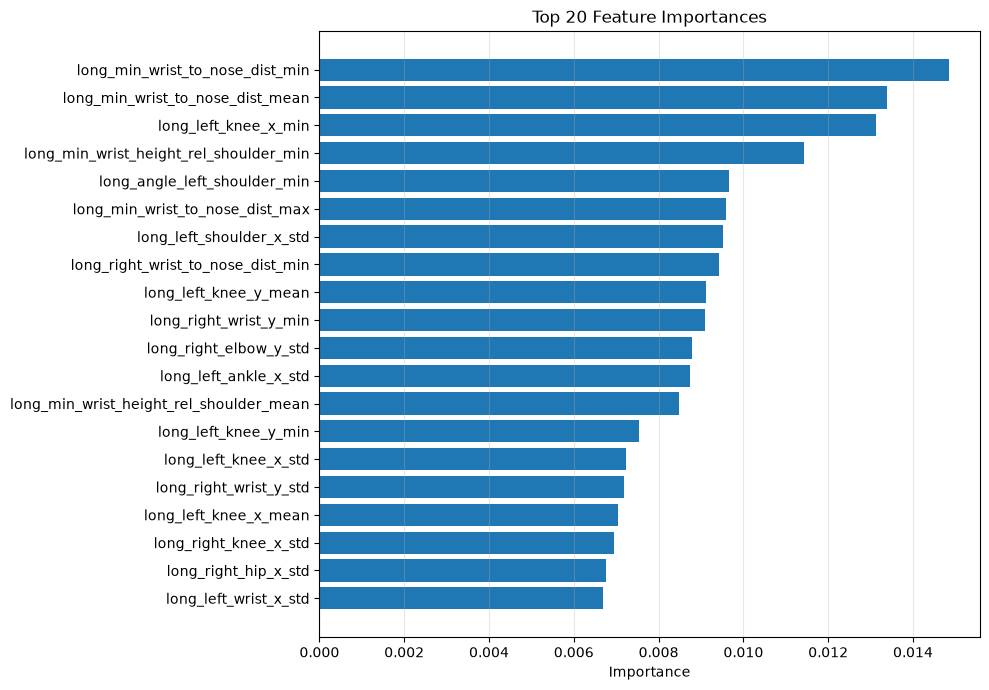

In [9]:
# Feature importance analysis for Window Size: (15, 90) | Window Stride: 5
all_subject_norm = preprocess_all_subjects(all_subject, window_size=(15, 90), stride=5)
importance_df = get_feature_importance(all_subject_norm, top_n=20)

## Feature Importance-Based Feature Selection / 特徴量重要度に基づく特徴量選択

The effect of feature selection is evaluated by retaining the **top 50, 100, 150, and 200** most important features ranked by the Random Forest feature importance scores. A Random Forest classifier is then trained and evaluated on each feature subset to examine how the number of selected features influences classification performance.

Random Forest による特徴量重要度を用いて、**上位50、100、150、200個**の特徴量を選択し、それぞれの特徴量セットでモデルを学習・評価します。これにより、使用する特徴量数が分類性能に与える影響を確認します。

In [14]:
# ==========================================
# Window Size: (15, 90) | Stride: 5
# ==========================================
results = []
# Try four different cutoffs for feature importance filtering and evaluate the model performance with each subset of features
# 特徴量重要度のフィルタリングに対して3つの異なるカットオフを試し、各特徴量サブセットでモデルの性能を評価する
for top_n in [50, 100, 150, 200]:
    filtered_subjects = filter_features_by_importance(
        all_subject_norm,
        importance_df,
        top_n=top_n
    )
    rf = model_random_forest()
    fold_results = evaluate_loso(filtered_subjects, rf);

    scores = [v["macro_f1"] for v in fold_results.values()]
    mean = np.mean(scores)
    std = np.std(scores)
    results.append({
        "Top Features Count": top_n,
        "Mean Macro F1": mean,
        "Std": std
    })

top_features_summary_df = (
pd.DataFrame(results)
  .sort_values(
      by=["Mean Macro F1", "Std"],
      ascending=[False, True]
  )
  .reset_index(drop=True)
)

top_features_summary_df

Features kept: 50
Features dropped: 894
Features kept: 100
Features dropped: 844
Features kept: 150
Features dropped: 794
Features kept: 200
Features dropped: 744


,Top Features Count,Mean Macro F1,Std
0,50,0.523274,0.120535
1,100,0.509977,0.107408
2,150,0.507227,0.125840
3,200,0.494249,0.119129


## Effect of Removing Low-Quality Frames / 低品質フレーム除外の影響評価

This experiment compares model performance with and without removing frames that have abnormally small shoulder widths. The objective is to determine whether filtering these potentially unreliable pose estimations improves classification performance or whether the additional preprocessing step has little impact.

この実験では、肩幅が異常に小さいフレームを**除外した場合**と**除外しない場合**でモデル性能を比較します。目的は、このような信頼性の低い姿勢推定結果を除外することが分類性能の向上につながるか、あるいは前処理としての効果が限定的であるかを評価することです.

In [ ]:
drop_bad_frames = [False, True]
result = []
window_size = (15, 90)
window_stride = 5

for dbf in drop_bad_frames:
    
    model = model_random_forest()
    filtered_subjects = filter_features_by_importance(
        all_subject_norm,
        importance_df,
        top_n=top_n
    )
    fold_results = preprocess_evaluate_loso_supervised(
        all_subject=all_subject,
        model=model,
        window_size=window_size,
        stride=stride
    )

    scores = [v["macro_f1"] for v in fold_results.values()]
    mean = np.mean(scores)
    std = np.std(scores)

    results.append({
        "Window Size": window_size,
        "Stride": stride,
        "Mean Macro F1": mean,
        "Std": std
    })

drop_bad_frames_summary_df = (
    pd.DataFrame(results)
      .sort_values(
          by=["Mean Macro F1", "Std"],
          ascending=[False, True]
      )
      .reset_index(drop=True)
)

drop_bad_frames_summary_df

# Optuna

In [16]:
# Run on your best configuration — top 100 features
filtered_100 = filter_features_by_importance(
    all_subject_norm, importance_df, top_n=100
)

study = run_optuna_study(filtered_100, n_trials=50)

Features kept: 100
Features dropped: 844
Subjects processed: ['1', '2', '3', '5']

               
OPTUNA SEARCH  —  50 trials  |  4 LOSO folds each               


Tuning:  16%|█▌        | 8/50 [04:52<24:37, 35.19s/trial][W 2026-06-14 01:02:57,203] Trial 8 failed with parameters: {'n_estimators': 300, 'max_depth': None, 'min_samples_leaf': 10, 'min_samples_split': 11, 'max_features': 'sqrt'} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/optuna/study/_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
  File "/Users/sozolab/Documents/GitHub/pose-based-human-activity-recognition/har_utils/analysis.py", line 403, in <lambda>
  File "/Users/sozolab/Documents/GitHub/pose-based-human-activity-recognition/har_utils/analysis.py", line 7, in optuna_objective_loso
    from har_utils.preprocessing import preprocess_all_subjects
            ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/base.py", line 1336, in wrapper
    return fit_m

KeyboardInterrupt: 

In [ ]:
best_model = model_random_forest(
    **study.best_params,
    random_state=42,
    n_jobs=-1
)

results = evaluate_loso(filtered_100, model_param=best_model, model_type=None);


────────────────────────────────────────────────────
  Fold — Test Subject: 1  |  Train: ['2', '3', '5']
────────────────────────────────────────────────────
  Class                  Precision    Recall        F1
  ────────────────────── ───────── ───────── ─────────
  Attacking                   0.44      0.25      0.32
  Biting                      0.00      0.00      0.00
  Eating snacks               0.57      1.00      0.72
  Head banging                0.98      0.67      0.79
  Sitting quietly             0.87      0.97      0.92
  Throwing things             0.49      0.53      0.51
  Using phone                 1.00      0.32      0.49
  Walking                     0.83      0.99      0.91

  Macro F1: 0.582

────────────────────────────────────────────────────
  Fold — Test Subject: 2  |  Train: ['1', '3', '5']
────────────────────────────────────────────────────
  Class                  Precision    Recall        F1
  ────────────────────── ───────── ───────── ─────────
  A

# Experiment Results Summary

## Evaluation Methodology
- **Dataset**: 4 subjects performing 8 activities (4 normal, 4 abnormal)
- **Evaluation**: Leave-One-Subject-Out Cross-Validation (LOSO)
- **Metric**: Macro F1 Score (unweighted average across all 8 classes)
- **Activities**: Attacking, Biting, Eating snacks, Head banging, Sitting quietly, Throwing things, Using phone, Walking

---

## Overall LOSO Performance Across Experiments

| # | Configuration | Model | Mean F1 | Std | Notes |
|---|---|---|---|---|---|
| 1 | Frame-level coordinates only | Random Forest (default) | 0.397 | 0.122 | Baseline after y-normalization fix |
| 2 | + Angle features | Random Forest (default) | 0.530 | — | Single test subject only |
| 3 | + Range of motion features | Random Forest (default) | 0.530 | — | Single test subject only |
| 4 | Windowed features (size=30, stride=10) | Random Forest (default) | 0.397 | 0.122 | First LOSO benchmark |
| 5 | Multi-scale windows (15, 60) + acceleration | Random Forest (default) | 0.472 | 0.115 | Multi-scale introduced |
| 6 | Multi-scale windows (15, 90) + acceleration | Random Forest (default) | 0.472 | 0.115 | No improvement over (15,60) |
| 7 | Multi-scale windows (15, 120) + acceleration | Random Forest (default) | 0.486 | 0.140 | Best window configuration |
| 8 | Top 100 features (15, 120) | Random Forest (default) | 0.508 | 0.106 | Best mean + lowest std |
| 9 | Top 150 features (15, 120) | Random Forest (default) | 0.488 | 0.117 | Diminishing returns |
| 10 | Top 200 features (15, 120) | Random Forest (default) | 0.474 | 0.122 | Worse than top 100 |
| 11 | Top 100 features (15, 120) | HistGradientBoosting | 0.496 | 0.117 | Underperforms RF |
| 12 | Top 150 features (15, 120) | HistGradientBoosting | 0.473 | 0.142 | High variance |
| 13 | Top 200 features (15, 120) | HistGradientBoosting | 0.460 | 0.146 | Worst HGB result |
| **14** | **Top 100 features (15, 120), Optuna-tuned** | **Random Forest** | **0.554** | **0.117** | **Best overall result** |

---

## Best Configuration — Per-Subject Breakdown

**Random Forest | Top 100 Features | Window (15, 120) | Optuna-tuned**

`n_estimators=400, max_depth=10, min_samples_leaf=21, min_samples_split=4, max_features=log2`

| Subject | Macro F1 | Notes |
|---|---|---|
| Subject 1 | 0.582 | Strong improvement from tuning |
| Subject 2 | 0.655 | Best performing fold |
| Subject 3 | 0.357 | Consistently hardest subject |
| Subject 5 | 0.622 | Good generalisation |
| **Mean** | **0.554** | |
| **Std** | **0.117** | |

---

## Best Configuration — Per-Class F1 (Averaged Across Folds)

| Class | Type | Avg F1 | Notes |
|---|---|---|---|
| Walking | Normal | ~0.95 | Consistently well recognised |
| Head banging | Abnormal | ~0.76 | Strong, benefits from motion signal |
| Attacking | Abnormal | ~0.51 | Variable across subjects |
| Throwing things | Abnormal | ~0.68 | Reliable across folds |
| Sitting quietly | Normal | ~0.65 | Improved significantly with tuning |
| Eating snacks | Normal | ~0.52 | Dominant class, absorbs confusions |
| Using phone | Normal | ~0.12 | Fundamentally hard to distinguish |
| Biting | Abnormal | ~0.16 | Feature space overlap with Eating snacks |

---

## Key Findings

| Finding | Detail |
|---|---|
| **Normalization bug** | y-coordinates were being centered using hip_center_x instead of hip_center_y. Fixing this was the single most impactful change. |
| **Torso height scaling** | Replacing shoulder-width normalization with torso height improved cross-subject consistency of wrist height features. |
| **Multi-scale windowing** | Combining a 15-frame short window with a 120-frame long window outperformed any single window size. |
| **Feature engineering** | Wrist-to-nose distance and wrist height relative to shoulder were the top two features by importance. |
| **Feature selection** | 100 features outperformed 944. The importance distribution was flat — most features were noise. |
| **Hyperparameter tuning** | min_samples_leaf=21 (vs default 1) was the key generalisation improvement found by Optuna. |
| **Subject variability** | Subject 3 scores ~0.36 across all configurations — a structural data challenge, not a model limitation. |
| **Fundamental ceiling** | Biting and Using phone overlap with Eating snacks in feature space. Confirmed by distribution plots and consistent with the published paper on this dataset. |

---

## Improvement Trajectory

| Stage | Mean LOSO F1 | Gain |
|---|---|---|
| Initial baseline | 0.397 | — |
| Multi-scale windowing | 0.486 | +0.089 |
| Feature selection (top 100) | 0.508 | +0.022 |
| Optuna hyperparameter tuning | 0.554 | +0.046 |
| **Total improvement** | | **+0.157 (+39.5%)** |